In [1]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0


In [2]:
image_size=(128,128)
batch_size=32
seed=42

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("princelv84/dogsvscats")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/princelv84/dogsvscats


In [4]:
train_path=path+"/train"
classes=os.listdir(train_path)
print(classes)

['dogs', 'cats']


In [5]:
for c in classes:
  print(c,len(os.listdir(train_path+"/"+c)))

dogs 10000
cats 10000


# **EDA**

(261, 350, 3)


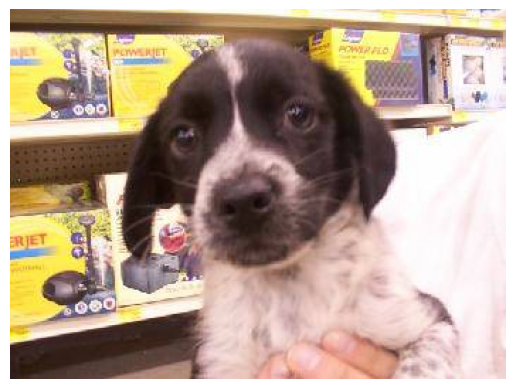

(374, 500, 3)


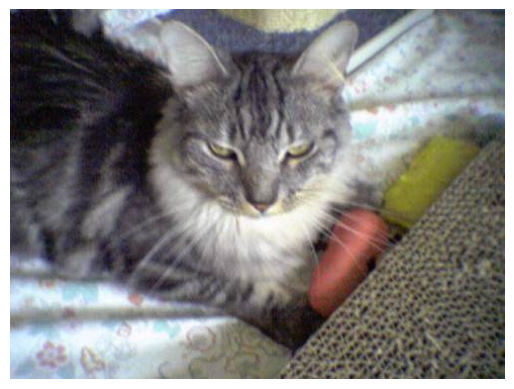

In [6]:
for c in classes:
  images=os.listdir(train_path+"/"+c)
  image_name=random.choice(images)
  image_path=train_path+"/"+c+"/"+image_name
  image = cv2.imread(image_path)
  print(image.shape)
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  plt.imshow(image_rgb)
  plt.axis("off")
  plt.show()

In [7]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=image_size,
    batch_size=batch_size,
    validation_split=.2,
    subset="training",
    seed=seed
)


Found 20000 files belonging to 2 classes.
Using 16000 files for training.


I0000 00:00:1791027077.881840      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791027077.886697      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=image_size,
    batch_size=batch_size,
    validation_split=.2,
    subset="validation",
    seed=seed
)

Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [10]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(2, activation="softmax")
])

In [12]:
model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "best_cats_dogs_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
]

In [15]:
history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


E0000 00:00:1791027096.363866      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 118ms/step - accuracy: 0.9352 - loss: 0.1719 - val_accuracy: 0.9743 - val_loss: 0.0656 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9496 - loss: 0.1264 - val_accuracy: 0.9783 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9542 - loss: 0.1144 - val_accuracy: 0.9758 - val_loss: 0.0620 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9555 - loss: 0.1101 - val_accuracy: 0.9770 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9611 - loss: 0.0972 - val_accuracy: 0.9758 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.9628 - loss: 0.0926 - val_accuracy: 0.9803 - val_loss: 0.0571 - learning_rate: 5.0000e-04
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9680 - loss: 0

In [16]:
test_path = path + "/test"
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=batch_size
)



Found 5000 files belonging to 2 classes.


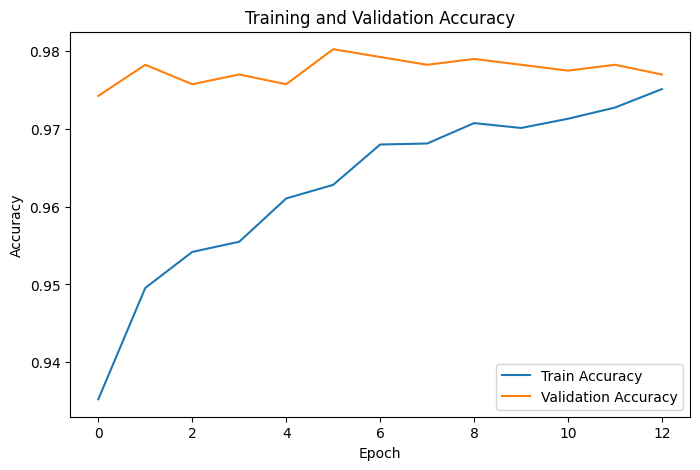

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

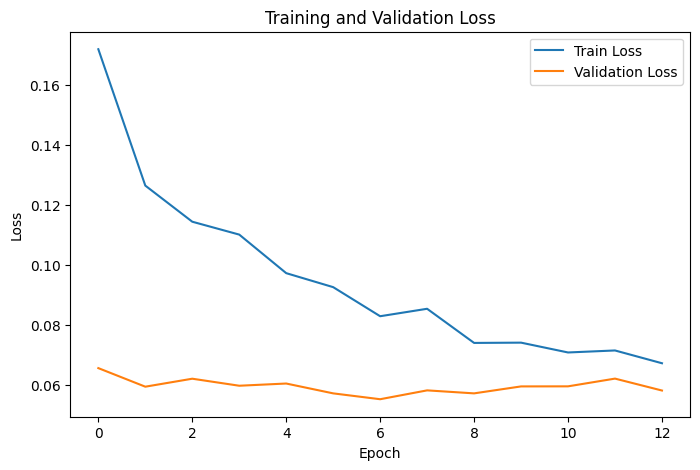

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [19]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1956
           1       0.98      0.98      0.98      2044

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2500
           1       0.98      0.97      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



In [21]:
model.save("/kaggle/working/cats_dogs_efficientnetb0.keras")

In [22]:
import os

print(os.path.exists("/kaggle/working/cats_dogs_efficientnetb0.keras"))

True
